In [ ]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from pathlib import Path


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Define Data Paths

In [ ]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

DATA_DIR


PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw')

In [ ]:
# Confirm Data Path
list[Path](DATA_DIR.glob("*.csv"))



[PosixPath('/Users/jack.lewittes/Desktop/MacBook/My_Coding/Python/Python_Data_Analytics_Course-main/NFL_Analytics_01/data/raw/basic_stats.csv')]

In [8]:
basic_df = pd.read_csv(DATA_DIR / "basic_stats.csv")
basic_df.head()

,Age,Birth Place,Birthday,College,Current Status,Current Team,Experience,Height (inches),High School,High School Location,Name,Number,Player Id,Position,Weight (lbs),Years Played
0,NaN,"Grand Rapids , MI",5/23/1921,Notre Dame,Retired,NaN,3 Seasons,71.0,NaN,NaN,"Evans, Fred",NaN,fredevans/2513736,NaN,185.0,1946 - 1948
1,NaN,"Dayton , OH",12/21/1930,Dayton,Retired,NaN,1 Season,70.0,NaN,NaN,"Raiff, Jim",NaN,jimraiff/2523700,NaN,235.0,1954 - 1954
2,56.0,"Temple , TX",9/11/1960,Louisiana Tech,Retired,NaN,1 Season,74.0,NaN,NaN,"Fowler, Bobby",NaN,bobbyfowler/2514295,NaN,230.0,1985 - 1985
3,30.0,"New Orleans , LA",9/30/1986,LSU,Retired,NaN,5 Seasons,73.0,NaN,NaN,"Johnson, Quinn",NaN,quinnjohnson/79593,NaN,255.0,2009 - 2013
4,25.0,"Detroit , MI",3/31/1992,Central Michigan,Active,Pittsburgh Steelers,3rd season,77.0,Clintondale HS,"Clinton Twp.,Macomb Co., MI","Walton, L.T.",96.0,l.t.walton/2552444,DE,305.0,NaN


In [11]:
qb_game_logs_df = pd.read_csv(DATA_DIR / "Game_Logs_Quarterback.csv")
qb_game_logs_df

,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Ints,Sacks,Sacked Yards Lost,Passer Rating,Rushing Attempts,Rushing Yards,Yards Per Carry,Rushing TDs,Fumbles,Fumbles Lost
0,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,1,08/11,Home,CHI,L,...,--,--,--,0.0,--,--,--,--,--,--
1,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,2,08/18,Away,ARI,W,...,0,0,0,46.9,--,--,--,--,--,--
2,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,3,08/25,Home,DAL,W,...,--,--,--,0.0,--,--,--,--,--,--
3,jaredzabransky/2495791,"Zabransky, Jared",NaN,2007,Preseason,4,08/30,Away,TB,L,...,1,2,13,50.8,2,17,8.5,0,--,--
4,billdemory/2512778,"Demory, Bill",NaN,1974,Regular Season,1,09/15,Away,KC,L,...,--,--,--,0.0,--,--,--,--,--,--
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40242,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,12,12/05,Home,CHI,W,...,2,3,27,25.3,2,0,0.0,0,--,--
40243,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,13,12/12,Away,SD,L,...,3,1,6,37.3,--,--,--,--,--,--
40244,steveramsey/2523725,"Ramsey, Steve",NaN,1971,Regular Season,14,12/19,Away,OAK,L,...,1,2,13,57.5,1,6,6.0,0,--,--
40245,steveramsey/2523725,"Ramsey, Steve",NaN,1970,Regular Season,13,12/13,Home,SF,L,...,--,--,--,0.0,--,--,--,--,--,--


In [ ]:
qb_game_logs_df = qb_game_logs_df[qb_game_logs_df["Year"] >= 1982].copy()
qb_game_logs_df.sort_values(by="Year", inplace=True, ascending=False)
qb_game_logs_df.fillna(0, inplace=True)


,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Ints,Sacks,Sacked Yards Lost,Passer Rating,Rushing Attempts,Rushing Yards,Yards Per Carry,Rushing TDs,Fumbles,Fumbles Lost
22419,camnewton/2495455,"Newton, Cam",QB,2016,Regular Season,17,1900-01-01,Away,TB,L,...,3,3,30,51.2,3,6,2.0,0,--,--


In [ ]:
qb_game_logs_df_sorted = qb_game_logs_df.sort_values(
    by=["Passer Rating", "Name", "Year"],
    ascending=[False, True, True]
)
qb_game_logs_df_sorted.head(30)

# Remove any row where "Season" is "Preseason"
qb_game_logs_df_sorted = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Season"] != "Preseason"]
qb_high_rating_df = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Passer Rating"].apply(pd.to_numeric, errors='coerce') >= 90]
qb_high_rating_df.head()



,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Ints,Sacks,Sacked Yards Lost,Passer Rating,Rushing Attempts,Rushing Yards,Yards Per Carry,Rushing TDs,Fumbles,Fumbles Lost
28306,derekanderson/2506546,"Anderson, Derek",QB,2014,Regular Season,3,1900-09-21,Home,PIT,L,...,0,0,0,158.3,--,--,--,--,--,--
1359,stevebartkowski/2509103,"Bartkowski, Steve",0,1984,Regular Season,4,1900-09-23,Home,HOU,W,...,0,2,10,158.3,1,0,0.0,0,--,--
1960,charliebatch/2499567,"Batch, Charlie",0,2005,Regular Season,16,1900-12-24,Away,CLE,W,...,0,0,0,158.3,--,--,--,--,--,--
16740,kerwinbell/2499604,"Bell, Kerwin",0,1996,Regular Season,15,1900-12-05,Home,PHI,W,...,0,0,0,158.3,1,-1,-1.0,0,--,--
10784,tombrady/2504211,"Brady, Tom",QB,2007,Regular Season,7,1900-10-21,Away,MIA,W,...,0,1,10,158.3,--,--,--,--,--,--


In [ ]:
positive_passer_rating_appearances = (qb_high_rating_df['Name']
.value_counts()
.rename_axis('Name')
.reset_index(name='Positive Passer Rating Appearences')
)
# QB's who aggregated at least 4 Season of "Strong Play" (assume 16 games per Season)
positive_passer_rating_appearances
top_qbs_40plus_games = positive_passer_rating_appearances[positive_passer_rating_appearances["Positive Passer Rating Appearences"] >= 40]
top_qbs_40plus_games


,Name,Positive Passer Rating Appearences
0,"Manning, Peyton",176
1,"Brady, Tom",159
2,"Favre, Brett",155
3,"Brees, Drew",147
4,"Roethlisberger, Ben",114
5,"Rodgers, Aaron",110
6,"Rivers, Philip",110
7,"Marino, Dan",108
8,"Young, Steve",106
9,"Elway, John",103


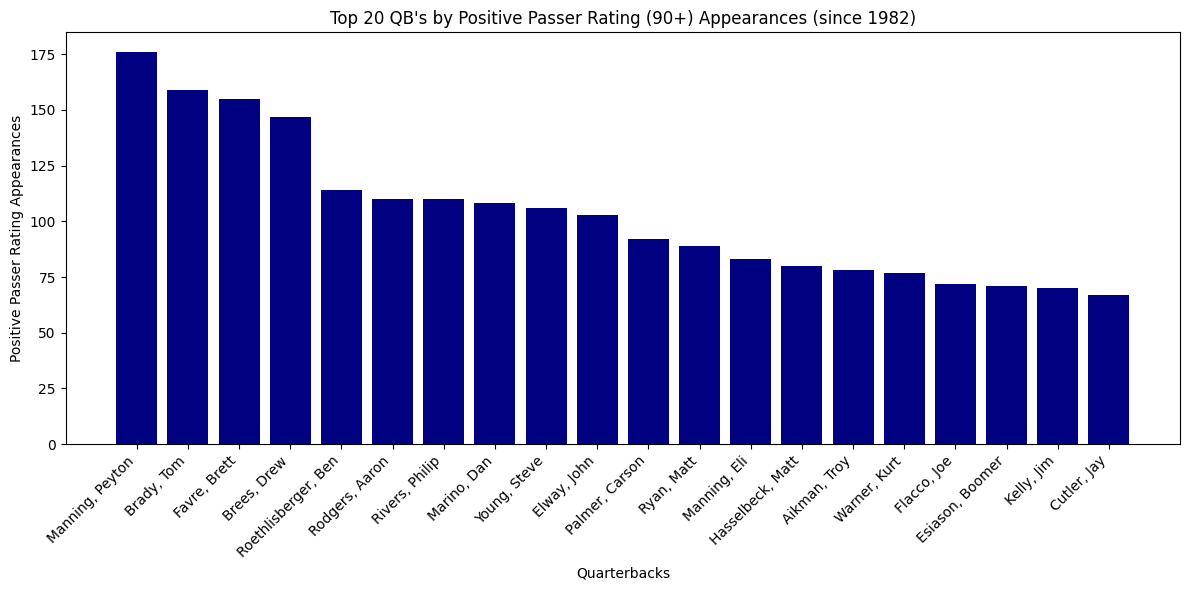

In [44]:

# Get top 20 QBs
top_20_qbs = top_qbs_40plus_games.head(20)

# Plot the bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(top_20_qbs["Name"], top_20_qbs["Positive Passer Rating Appearences"], color='navy')
plt.xlabel("Quarterbacks")
plt.ylabel("Positive Passer Rating Appearances")
plt.title("Top 20 QB's by Positive Passer Rating (90+) Appearances (since 1982)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




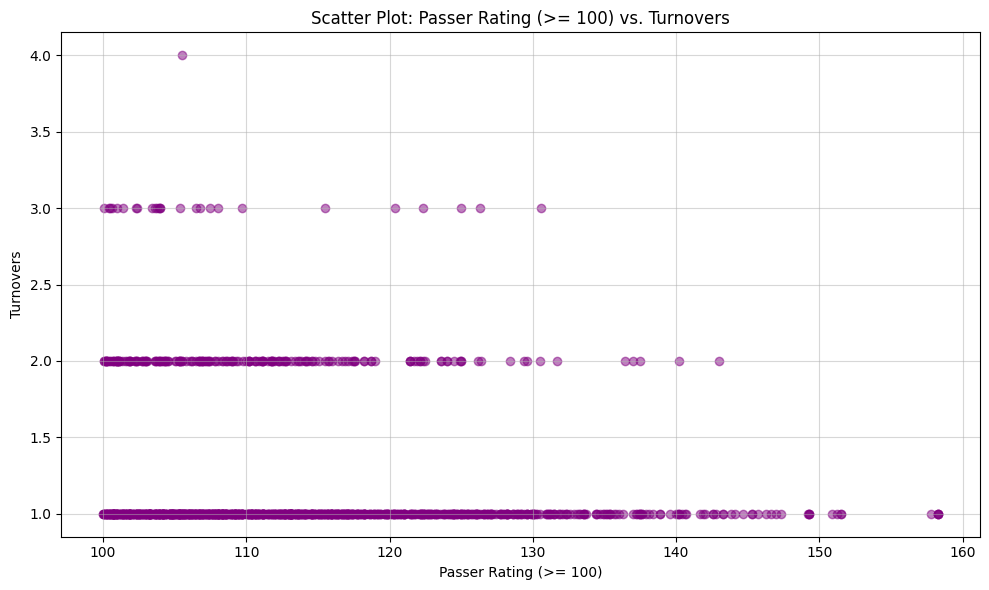

In [56]:
# Filter for games with Passer Rating >= 100
qb_high_rating_100_df = qb_game_logs_df_sorted[qb_game_logs_df_sorted["Passer Rating"].apply(pd.to_numeric, errors="coerce") >= 100].copy()

# Ensure Ints and Fumbles Lost are numeric (coerce errors to NaN then fill NaN with 0) and convert
qb_high_rating_100_df["Ints"] = pd.to_numeric(qb_high_rating_100_df["Ints"], errors="coerce").fillna(0)
qb_high_rating_100_df["Fumbles Lost"] = pd.to_numeric(qb_high_rating_100_df["Fumbles Lost"], errors="coerce").fillna(0)
qb_high_rating_100_df["Turnovers"] = qb_high_rating_100_df["Ints"] + qb_high_rating_100_df["Fumbles Lost"]

# Filter to only games with at least 1 turnover (Int + Fumbles Lost > 0)
qb_high_rating_100_turnover_games = qb_high_rating_100_df[qb_high_rating_100_df["Turnovers"] > 0]

# Display resulting DataFrame
qb_high_rating_100_turnover_games

# Scatter plot between Passer Rating (>=100) and Turnovers (where turnovers > 0)
plt.figure(figsize=(10, 6))
plt.scatter(qb_high_rating_100_turnover_games["Passer Rating"], qb_high_rating_100_turnover_games["Turnovers"], alpha=0.5, color='purple')
plt.xlabel("Passer Rating (>= 100)")
plt.ylabel("Turnovers")
plt.title("Scatter Plot: Passer Rating (>= 100) vs. Turnovers")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:

# Correlation between Passer Rating (QBR) and Outcome
# For this, let's map 'Outcome' to numeric (W=1, L=0, T=0.5 or N/A if other)

# Copy dataframe to work with
qb_game_logs_corr = qb_game_logs_df_sorted.copy()

# Parse Passer Rating and Outcome columns
qb_game_logs_corr["Passer Rating"] = pd.to_numeric(qb_game_logs_corr["Passer Rating"], errors="coerce")

# Map Outcome to numeric: 'W' -> 1, 'L' -> 0, 'T' -> 0.5, handle case insensitivity and missing values
def outcome_to_numeric(outcome):
    if isinstance(outcome, str):
        s = outcome.strip().upper()
        if s == "W":
            return 1
        elif s == "L":
            return 0
        elif s == "T":
            return 0.5
    return None

qb_game_logs_corr["Outcome_Numeric"] = qb_game_logs_corr["Outcome"].apply(outcome_to_numeric)

# Drop rows missing either Passer Rating or Outcome_Numeric
qbr_outcome_valid = qb_game_logs_corr.dropna(subset=["Passer Rating", "Outcome_Numeric"])

# Group Passer Rating by Outcome_Numeric for boxplot
data_by_outcome = [
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 0]["Passer Rating"].values,  # Loss
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 0.5]["Passer Rating"].values,  # Tie
    qbr_outcome_valid[qbr_outcome_valid["Outcome_Numeric"] == 1]["Passer Rating"].values   # Win
]

plt.figure(figsize=(10,6))
plt.boxplot(data_by_outcome, labels=["Loss", "Tie", "Win"])
plt.xlabel("Outcome")
plt.ylabel("Passer Rating")
plt.title("Boxplot: Passer Rating vs. Game Outcome")
plt.grid(True, alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

# Correlation between Turnovers and Outcome
# Use the already prepared Ints and Fumbles Lost columns (numeric & filled), create Turnovers if not already made.

# Make sure Turnovers column exists and is correct, repeat conversion if not:
qb_game_logs_corr["Ints"] = pd.to_numeric(qb_game_logs_corr["Ints"], errors="coerce").fillna(0)
qb_game_logs_corr["Fumbles Lost"] = pd.to_numeric(qb_game_logs_corr["Fumbles Lost"], errors="coerce").fillna(0)
qb_game_logs_corr["Turnovers"] = qb_game_logs_corr["Ints"] + qb_game_logs_corr["Fumbles Lost"]

# Drop rows missing Turnovers or Outcome_Numeric
turnover_outcome_valid = qb_game_logs_corr.dropna(subset=["Turnovers", "Outcome_Numeric"])

# plt.figure(figsize=(10,6))
plt.scatter(turnover_outcome_valid["Turnovers"], turnover_outcome_valid["Outcome_Numeric"], alpha=0.25, color='crimson')
plt.xlabel("Turnovers (INT + Fumbles Lost)")
plt.ylabel("Outcome (Win=1, Loss=0, Tie=0.5)")
plt.title("Scatter Plot: Turnovers vs. Game Outcome")
plt.yticks([0,0.5,1], ["Loss","Tie","Win"])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()




TypeError: box() takes from 0 to 1 positional arguments but 2 were given